In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df= pd.read_csv('subscription_churn_dirty_dataset.csv')
df.head()

,Subscriber_ID,Name,Age,Gender,Subscription_Type,Subscription_Tenure_Months,Monthly_Subscription_Fee,Usage_Hours_Per_Week,Days_Since_Last_Login,Payment_Failure_Count,Customer_Support_Tickets,Customer_Satisfaction_Score,Device_Type,City,Churn_Status
0,SUB100000,Ira Varughese,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,SUB100001,Nitya Dey,NaN,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1
2,SUB100002,Ryan Dhaliwal,44.0,Male,Standard,23,1637.0,17.4,112,6,13,NaN,Tablet,Hyderabad,1
3,SUB100003,Oorja Saxena,31.0,Female,Premium,33,2271.0,6.0,82,3,5,1.0,Mobile,Pune,0
4,SUB100004,Inaaya Keer,31.0,Male,Basic,36,1419.0,1.7,31,2,14,7.0,Laptop,Jaipur,1


In [3]:
ds= df.copy()

# 1. Understanding data

In [4]:
ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20760 entries, 0 to 20759
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Subscriber_ID                20760 non-null  object 
 1   Name                         20715 non-null  object 
 2   Age                          19787 non-null  float64
 3   Gender                       20760 non-null  object 
 4   Subscription_Type            20760 non-null  object 
 5   Subscription_Tenure_Months   20760 non-null  int64  
 6   Monthly_Subscription_Fee     19801 non-null  float64
 7   Usage_Hours_Per_Week         19767 non-null  float64
 8   Days_Since_Last_Login        20760 non-null  int64  
 9   Payment_Failure_Count        20760 non-null  int64  
 10  Customer_Support_Tickets     20760 non-null  int64  
 11  Customer_Satisfaction_Score  19770 non-null  float64
 12  Device_Type                  20760 non-null  object 
 13  City            

In [5]:
ds.describe()

,Age,Subscription_Tenure_Months,Monthly_Subscription_Fee,Usage_Hours_Per_Week,Days_Since_Last_Login,Payment_Failure_Count,Customer_Support_Tickets,Customer_Satisfaction_Score,Churn_Status
count,19787.000000,20760.000000,19801.000000,19767.000000,20760.000000,20760.000000,20760.000000,19770.000000,20760.000000
mean,44.335574,36.108478,2808.559871,22.530409,89.604335,3.540414,6.991378,5.509307,0.491570
std,19.950378,20.533444,9802.313064,12.963579,51.927489,2.285745,4.312325,2.874962,0.499941
min,-5.000000,1.000000,99.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
25%,31.000000,19.000000,723.000000,11.300000,44.000000,2.000000,3.000000,3.000000,0.000000
50%,44.000000,36.000000,1343.000000,22.500000,90.000000,4.000000,7.000000,6.000000,0.000000
75%,57.000000,54.000000,1963.000000,33.900000,135.000000,6.000000,11.000000,8.000000,1.000000
max,200.000000,71.000000,99957.000000,45.000000,179.000000,7.000000,14.000000,10.000000,1.000000


In [6]:
ds.columns= ds.columns.str.lower()

In [7]:
ds.head(2)

,subscriber_id,name,age,gender,subscription_type,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,device_type,city,churn_status
0,SUB100000,Ira Varughese,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,SUB100001,Nitya Dey,NaN,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1


# 2. Handling Missing Values¶

In [8]:
ds.isnull().sum()

subscriber_id                    0
name                            45
age                            973
gender                           0
subscription_type                0
subscription_tenure_months       0
monthly_subscription_fee       959
usage_hours_per_week           993
days_since_last_login            0
payment_failure_count            0
customer_support_tickets         0
customer_satisfaction_score    990
device_type                      0
city                             0
churn_status                     0
dtype: int64

In [9]:
# Categorical columns
ds['gender'] = ds['gender'].fillna(ds['gender'].mode()[0])
ds['subscription_type'] = ds['subscription_type'].fillna(ds['subscription_type'].mode()[0])
ds['device_type'] = ds['device_type'].fillna(ds['device_type'].mode()[0])
ds['city'] = ds['city'].fillna(ds['city'].mode()[0])

# Numeric columns
ds['age'] = ds['age'].fillna(ds['age'].median())
ds['subscription_tenure_months'] = ds['subscription_tenure_months'].fillna(ds['subscription_tenure_months'].median())
ds['monthly_subscription_fee'] = ds['monthly_subscription_fee'].fillna(ds['monthly_subscription_fee'].median())
ds['usage_hours_per_week'] = ds['usage_hours_per_week'].fillna(ds['usage_hours_per_week'].median())
ds['days_since_last_login'] = ds['days_since_last_login'].fillna(ds['days_since_last_login'].median())
ds['payment_failure_count'] = ds['payment_failure_count'].fillna(ds['payment_failure_count'].median())
ds['customer_support_tickets'] = ds['customer_support_tickets'].fillna(ds['customer_support_tickets'].median())
ds['customer_satisfaction_score'] = ds['customer_satisfaction_score'].fillna(ds['customer_satisfaction_score'].median())

# Target column
ds['churn_status'] = ds['churn_status'].fillna(ds['churn_status'].mode()[0])

In [10]:
ds.isnull().sum()

subscriber_id                   0
name                           45
age                             0
gender                          0
subscription_type               0
subscription_tenure_months      0
monthly_subscription_fee        0
usage_hours_per_week            0
days_since_last_login           0
payment_failure_count           0
customer_support_tickets        0
customer_satisfaction_score     0
device_type                     0
city                            0
churn_status                    0
dtype: int64

# 3. Handling Duplicates

In [11]:
if all(col in ds.columns for col in ['subscriber_id', 'name', 'churn_status']):
    ds = ds.drop_duplicates(
        subset=['subscriber_id', 'name', 'churn_status'],
        keep='first'
    )

elif all(col in ds.columns for col in ['subscriber_id', 'churn_status']):
    ds = ds.drop_duplicates(
        subset=['subscriber_id', 'churn_status'],
        keep='first'
    )

else:
    ds = ds.drop_duplicates(
        subset=[
            'subscription_type',
            'subscription_tenure_months',
            'monthly_subscription_fee',
            'usage_hours_per_week',
            'payment_failure_count',
            'customer_support_tickets',
            'device_type',
            'city',
            'churn_status'
        ],
        keep='first'
    )

ds.head(2)

,subscriber_id,name,age,gender,subscription_type,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,device_type,city,churn_status
0,SUB100000,Ira Varughese,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,SUB100001,Nitya Dey,44.0,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1


# 4. Remove Extra¶

In [12]:
ds.columns

Index(['subscriber_id', 'name', 'age', 'gender', 'subscription_type',
       'subscription_tenure_months', 'monthly_subscription_fee',
       'usage_hours_per_week', 'days_since_last_login',
       'payment_failure_count', 'customer_support_tickets',
       'customer_satisfaction_score', 'device_type', 'city', 'churn_status'],
      dtype='object')

In [13]:
cols = ['subscriber_id', 'name', 'age', 'gender', 'subscription_type',
       'subscription_tenure_months', 'monthly_subscription_fee',
       'usage_hours_per_week', 'days_since_last_login',
       'payment_failure_count', 'customer_support_tickets',
       'customer_satisfaction_score', 'device_type', 'city', 'churn_status']

ds = ds[cols]
ds.head(2)

,subscriber_id,name,age,gender,subscription_type,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,device_type,city,churn_status
0,SUB100000,Ira Varughese,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,SUB100001,Nitya Dey,44.0,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1


In [14]:
ds.head()

,subscriber_id,name,age,gender,subscription_type,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,device_type,city,churn_status
0,SUB100000,Ira Varughese,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,SUB100001,Nitya Dey,44.0,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1
2,SUB100002,Ryan Dhaliwal,44.0,Male,Standard,23,1637.0,17.4,112,6,13,6.0,Tablet,Hyderabad,1
3,SUB100003,Oorja Saxena,31.0,Female,Premium,33,2271.0,6.0,82,3,5,1.0,Mobile,Pune,0
4,SUB100004,Inaaya Keer,31.0,Male,Basic,36,1419.0,1.7,31,2,14,7.0,Laptop,Jaipur,1


# 4. Extracting Features

In [15]:
cols = ['age', 'gender', 'subscription_type',
       'subscription_tenure_months', 'monthly_subscription_fee',
       'usage_hours_per_week', 'days_since_last_login',
       'payment_failure_count', 'customer_support_tickets',
       'customer_satisfaction_score', 'device_type', 'city', 'churn_status']

ds = ds[cols]
ds.head(2)

,age,gender,subscription_type,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,device_type,city,churn_status
0,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,44.0,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1


In [16]:
ds['churn_status'].unique()

array([1, 0])

In [17]:
ds["churn_status"] = ds["churn_status"].replace(
    {"Yes": 1, "No": 0, "Y": 1, "N": 0, "yes": 1, "no": 0, "y": 1, "n": 0, '  Yes ': 1, '  No ': 0}
).astype(int)

In [18]:
ds['churn_status'].value_counts()

churn_status
0    10172
1     9840
Name: count, dtype: int64

# 5. Encoding

In [19]:
ds.head()

,age,gender,subscription_type,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,device_type,city,churn_status
0,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,44.0,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1
2,44.0,Male,Standard,23,1637.0,17.4,112,6,13,6.0,Tablet,Hyderabad,1
3,31.0,Female,Premium,33,2271.0,6.0,82,3,5,1.0,Mobile,Pune,0
4,31.0,Male,Basic,36,1419.0,1.7,31,2,14,7.0,Laptop,Jaipur,1


In [20]:
print(ds['gender'].unique())
print(ds['subscription_type'].unique())
print(ds['device_type'].unique())
print(ds['city'].unique())

ds['gender'].str.strip()
ds['subscription_type'].str.strip()
ds['device_type'].str.strip()
ds['city'].str.strip()

['Female' 'Male' 'Other' 'FEMALE' '??' 'male ' 'unknown']
['Basic' 'Premium' 'Standard' 'Family']
['Mobile' 'Laptop' 'Tablet' 'Smart TV']
['Nagpur' 'Delhi' 'Hyderabad' 'Pune' 'Jaipur' 'Ahmedabad' 'Mumbai'
 'Kolkata' 'Bangalore' 'Chennai']


0           Nagpur
1            Delhi
2        Hyderabad
3             Pune
4           Jaipur
           ...    
20460      Chennai
20577      Kolkata
20606         Pune
20620      Kolkata
20664      Kolkata
Name: city, Length: 20012, dtype: object

In [21]:
enc = pd.get_dummies(
    data=ds,
    columns=[
        'gender',
        'subscription_type',
        'device_type',
        'city'
    ],
    drop_first=True,
    dtype=int
)

ds = enc

ds.head(2)

,age,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,churn_status,gender_FEMALE,...,device_type_Tablet,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune
0,19.0,70,33448.0,17.6,113,2,6,7.0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,44.0,15,458.0,24.1,150,7,5,5.0,1,0,...,0,0,0,1,0,0,0,0,0,0


# 6. Train Test Split¶

In [22]:
X= ds.drop(columns=['churn_status'])
# y= ds[['churn']]
y= ds['churn_status']

In [23]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
X_train.shape, X_test.shape

((16009, 29), (4003, 29))

In [25]:
y_train.shape, y_test.shape

((16009,), (4003,))

# 7. Outlier remove

In [26]:
ds.head()

,age,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,churn_status,gender_FEMALE,...,device_type_Tablet,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune
0,19.0,70,33448.0,17.6,113,2,6,7.0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,44.0,15,458.0,24.1,150,7,5,5.0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,44.0,23,1637.0,17.4,112,6,13,6.0,1,0,...,1,0,0,0,1,0,0,0,0,0
3,31.0,33,2271.0,6.0,82,3,5,1.0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,31.0,36,1419.0,1.7,31,2,14,7.0,1,0,...,0,0,0,0,0,1,0,0,0,0


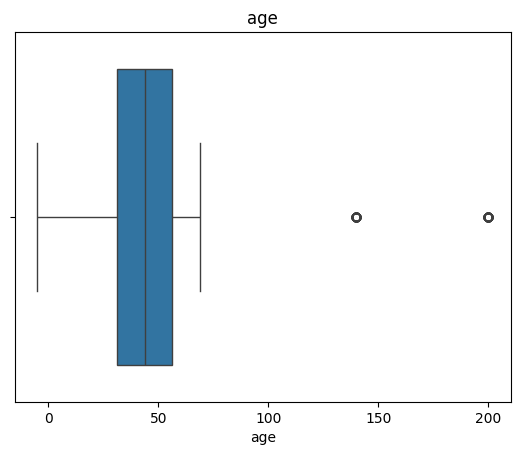

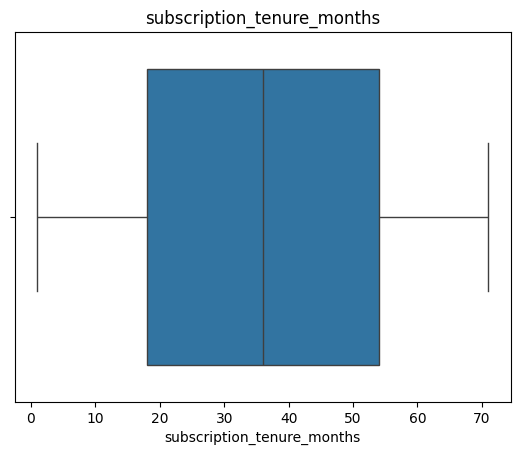

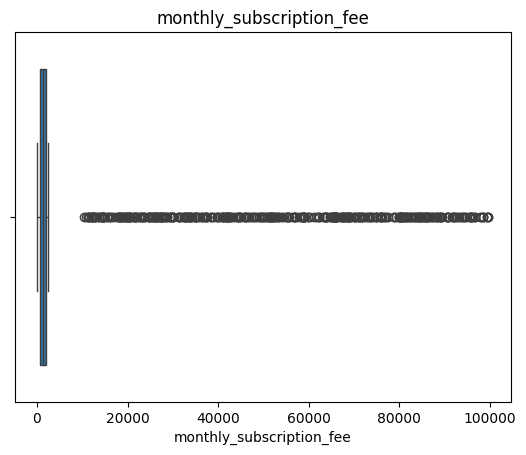

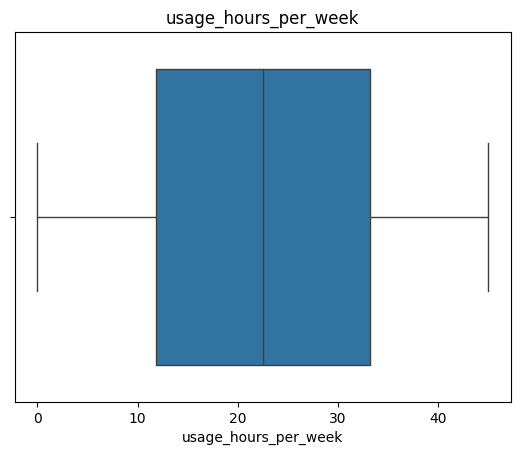

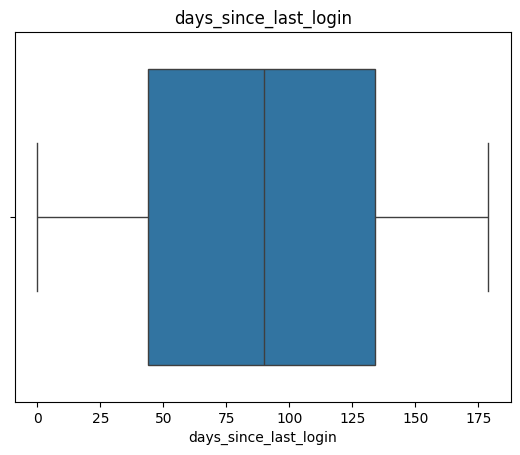

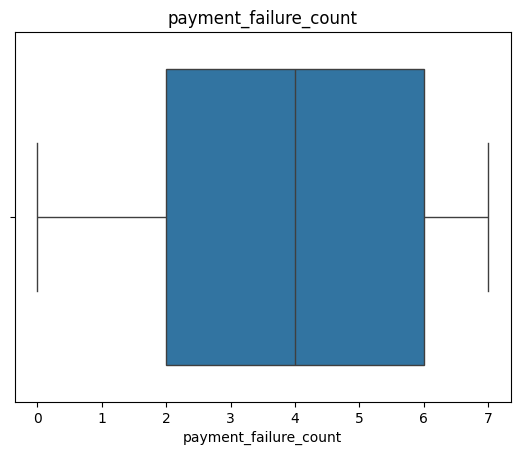

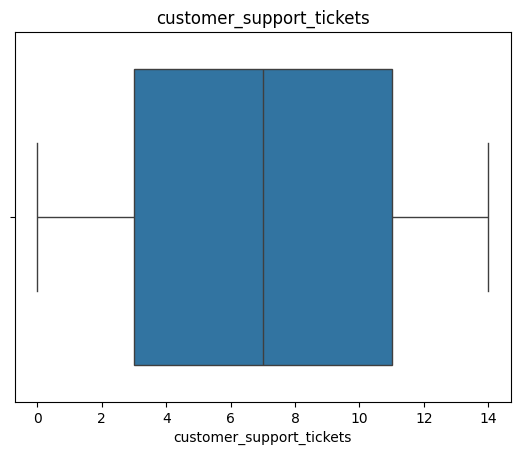

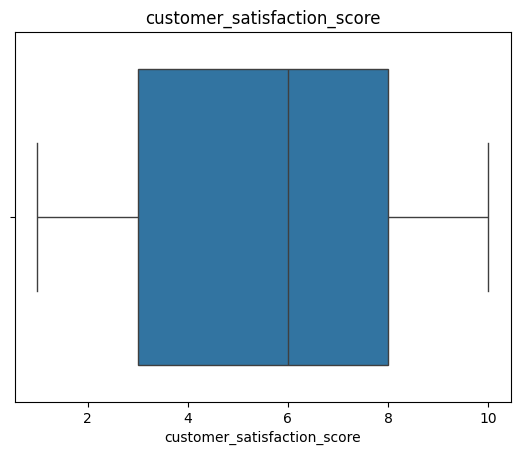

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in ['age', 'subscription_tenure_months', 'monthly_subscription_fee', 'usage_hours_per_week', 'days_since_last_login', 'payment_failure_count', 'customer_support_tickets', 'customer_satisfaction_score']:
    sns.boxplot(x=X_train[col])
    plt.title(col)
    plt.show()

In [28]:
def handle_outliers(ds, cols):
    for col in cols:
        Q1 = ds[col].quantile(0.25)
        Q3 = ds[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        # clip values
        ds[col] = ds[col].clip(lower, upper)

    return ds

In [29]:
num_cols = ['age', 'subscription_tenure_months', 'monthly_subscription_fee', 'usage_hours_per_week', 'days_since_last_login', 'payment_failure_count', 'customer_support_tickets', 'customer_satisfaction_score']

X_train = handle_outliers(X_train, num_cols)

# 8. Scaling data

In [30]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) # converted into array
X_test = scaler.transform(X_test)

# 9. Model Training

In [31]:
print(pd.DataFrame(X_train).isnull().sum())

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
dtype: int64


In [32]:
X_train = pd.DataFrame(X_train, columns=X.columns)
X_test = pd.DataFrame(X_test, columns=X.columns)

# again train model

In [58]:
from sklearn.svm import SVC

model_svm = SVC(
    kernel='rbf',
    C=1,
    gamma='scale',
    probability=True,
    random_state=42
)

model_svm.fit(X_train, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [59]:
from sklearn.ensemble import RandomForestClassifier
model_rf  = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42
)
model_rf .fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(

In [35]:
model_svm.score(X_train, y_train)

0.6383909051158724

In [60]:
model_svm.score(X_test, y_test)

0.6425181114164377

In [61]:
model_rf.score(X_train, y_train)

0.7078518333437441

In [62]:
model_rf.score(X_test, y_test)

0.6817386959780165

In [43]:
from xgboost import XGBClassifier
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.02,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model_xgb.fit(X_train, y_train)

C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [19:57:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [44]:
model_xgb.score(X_train, y_train)

0.7027297145355738

In [45]:
model_xgb.score(X_test, y_test)

0.6812390706969773

In [46]:
# Random Forest Prediction
rf_pred = model2.predict(X_test)

# XGBoost Prediction
xgb_pred = model_xgb.predict(X_test)

In [47]:
rf_pred

array([1, 1, 1, ..., 1, 0, 1], shape=(4003,))

In [48]:
xgb_pred

array([1, 1, 1, ..., 1, 0, 1], shape=(4003,))

In [49]:
# Check exact training columns
print(X.columns)

Index(['age', 'subscription_tenure_months', 'monthly_subscription_fee',
       'usage_hours_per_week', 'days_since_last_login',
       'payment_failure_count', 'customer_support_tickets',
       'customer_satisfaction_score', 'gender_FEMALE', 'gender_Female',
       'gender_Male', 'gender_Other', 'gender_male ', 'gender_unknown',
       'subscription_type_Family', 'subscription_type_Premium',
       'subscription_type_Standard', 'device_type_Mobile',
       'device_type_Smart TV', 'device_type_Tablet', 'city_Bangalore',
       'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur',
       'city_Kolkata', 'city_Mumbai', 'city_Nagpur', 'city_Pune'],
      dtype='object')


In [63]:
# =========================================
# Check Accuracy Of All Models
# Select Best Model Automatically
# =========================================

models = {
    "SVM": model_svm,
    "Random Forest": model_rf,
    "XGBoost": model_xgb
}

best_model_name = None
best_model = None
best_score = 0

print("\n===== MODEL COMPARISON =====\n")

for name, model in models.items():

    train_score = model.score(X_train, y_train)
    test_score = model.score(X_test, y_test)

    print(f"{name}")
    print(f"Training Accuracy : {train_score:.4f}")
    print(f"Testing Accuracy  : {test_score:.4f}")
    print("-" * 35)

    # Select Model With Highest Test Accuracy
    if test_score > best_score:
        best_score = test_score
        best_model_name = name
        best_model = model

# =========================================
# Best Model Result
# =========================================

print(f"\nBest Model Selected : {best_model_name}")
print(f"Best Accuracy : {best_score:.4f}")


===== MODEL COMPARISON =====

SVM
Training Accuracy : 0.7029
Testing Accuracy  : 0.6425
-----------------------------------
Random Forest
Training Accuracy : 0.7079
Testing Accuracy  : 0.6817
-----------------------------------
XGBoost
Training Accuracy : 0.7027
Testing Accuracy  : 0.6812
-----------------------------------

Best Model Selected : Random Forest
Best Accuracy : 0.6817


In [50]:
new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

In [51]:
new_customer['age'] = 25
new_customer['subscription_tenure_months'] = 12
new_customer['monthly_subscription_fee'] = 999
new_customer['usage_hours_per_week'] = 18.5
new_customer['days_since_last_login'] = 10
new_customer['payment_failure_count'] = 1
new_customer['customer_support_tickets'] = 2
new_customer['customer_satisfaction_score'] = 8

In [52]:
new_customer['gender_Female'] = 1

new_customer['subscription_type_Premium'] = 1

new_customer['device_type_Mobile'] = 1

new_customer['city_Nagpur'] = 1

In [53]:
new_customer_scaled = scaler.transform(new_customer)

In [64]:
prediction = best_model.predict(new_customer_scaled)

if prediction[0] == 1:
    print("Customer will leave")
else:
    print("Customer will stay")

Customer will stay


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [65]:
prob = best_model.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

# =========================================
# Show Best Model Details
# =========================================

print(f"\nPrediction Done Using : {best_model_name}")
print(f"Best Accuracy : {best_score:.4f}")


Stay Probability  : 88.75%
Leave Probability : 11.25%

Prediction Done Using : Random Forest
Best Accuracy : 0.6817


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [66]:
# =========================================
# Hyperparameter Tuning For Subscription
# Using XGBoost Only
# =========================================

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# =========================================
# XGBoost Parameter Grid
# =========================================

xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

# =========================================
# Base XGBoost Model
# =========================================

xgb = XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# =========================================
# Random Search Hyperparameter Tuning
# =========================================

random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=xgb_params,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

# =========================================
# Train Tuned Model
# =========================================

random_search.fit(X_train, y_train)

# =========================================
# Best Parameters
# =========================================

print("\nBest Parameters:\n")
print(random_search.best_params_)

# =========================================
# Best Tuned XGBoost Model
# =========================================

best_xgb = random_search.best_estimator_

# =========================================
# Accuracy Scores
# =========================================

train_score = best_xgb.score(X_train, y_train)
test_score = best_xgb.score(X_test, y_test)

print("\nTraining Accuracy :", train_score)
print("Testing Accuracy  :", test_score)

# =========================================
# Subscription Customer Prediction
# =========================================

new_customer = pd.DataFrame(0, index=[0], columns=X.columns)

new_customer['age'] = 25
new_customer['subscription_tenure_months'] = 12
new_customer['monthly_subscription_fee'] = 999
new_customer['usage_hours_per_week'] = 18.5
new_customer['days_since_last_login'] = 10
new_customer['payment_failure_count'] = 1
new_customer['customer_support_tickets'] = 2
new_customer['customer_satisfaction_score'] = 8

# Encoded Features
new_customer['gender_Female'] = 1
new_customer['subscription_type_Premium'] = 1
new_customer['device_type_Mobile'] = 1
new_customer['city_Nagpur'] = 1

# =========================================
# Scale Data
# =========================================

new_customer_scaled = scaler.transform(new_customer)

# =========================================
# Prediction
# =========================================

prediction = best_xgb.predict(new_customer_scaled)

if prediction[0] == 1:
    print("\nCustomer will leave")
else:
    print("\nCustomer will stay")

# =========================================
# Probability Prediction
# =========================================

prob = best_xgb.predict_proba(new_customer_scaled)

stay_prob = prob[0][0] * 100
leave_prob = prob[0][1] * 100

print(f"\nStay Probability  : {stay_prob:.2f}%")
print(f"Leave Probability : {leave_prob:.2f}%")

Fitting 3 folds for each of 10 candidates, totalling 30 fits


C:\Users\Chaitanya Gaikwad\AppData\Roaming\Python\Python313\site-packages\xgboost\training.py:199: UserWarning: [20:06:35] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best Parameters:

{'subsample': 0.7, 'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Training Accuracy : 0.6763070772690362
Testing Accuracy  : 0.6849862603047714

Customer will stay

Stay Probability  : 91.03%
Leave Probability : 8.97%


In [68]:
import joblib

# Save Model
joblib.dump(model_rf, "subscription_random_forest_model.pkl")

# Save Scaler
joblib.dump(scaler, "subscription_scaler.pkl")

print("Random Forest Model Saved Successfully")
print("Scaler Saved Successfully")

Random Forest Model Saved Successfully
Scaler Saved Successfully


In [55]:
ds.head()

,age,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,churn_status,gender_FEMALE,...,device_type_Tablet,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune
0,19.0,70,33448.0,17.6,113,2,6,7.0,1,0,...,0,0,0,0,0,0,0,0,1,0
1,44.0,15,458.0,24.1,150,7,5,5.0,1,0,...,0,0,0,1,0,0,0,0,0,0
2,44.0,23,1637.0,17.4,112,6,13,6.0,1,0,...,1,0,0,0,1,0,0,0,0,0
3,31.0,33,2271.0,6.0,82,3,5,1.0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,31.0,36,1419.0,1.7,31,2,14,7.0,1,0,...,0,0,0,0,0,1,0,0,0,0


In [56]:
X_train

,age,subscription_tenure_months,monthly_subscription_fee,usage_hours_per_week,days_since_last_login,payment_failure_count,customer_support_tickets,customer_satisfaction_score,gender_FEMALE,gender_Female,...,device_type_Tablet,city_Bangalore,city_Chennai,city_Delhi,city_Hyderabad,city_Jaipur,city_Kolkata,city_Mumbai,city_Nagpur,city_Pune
0,0.019939,1.352766,1.163758,-1.764355,1.592179,0.640210,-0.923678,-0.548993,-0.070868,1.107504,...,1.730970,-0.333692,-0.32718,-0.324952,-0.330794,-0.335308,-0.335999,-0.34241,-0.334847,-0.332766
1,0.650761,0.187267,0.848691,0.815531,-0.933174,1.514261,-1.155907,-0.548993,-0.070868,-0.902931,...,-0.577711,-0.333692,-0.32718,3.077376,-0.330794,-0.335308,-0.335999,-0.34241,-0.334847,-0.332766
2,1.155419,-1.658106,1.394893,-0.949238,1.515069,-0.670867,1.166380,1.596194,-0.070868,1.107504,...,-0.577711,-0.333692,-0.32718,3.077376,-0.330794,-0.335308,-0.335999,-0.34241,-0.334847,-0.332766
3,1.281583,1.304203,1.425883,1.147909,-0.412681,-0.670867,-1.155907,-0.548993,-0.070868,-0.902931,...,1.730970,-0.333692,-0.32718,-0.324952,-0.330794,-0.335308,2.976199,-0.34241,-0.334847,-0.332766
4,0.272268,1.352766,0.235343,-0.363619,0.821079,-0.670867,0.005237,0.166069,-0.070868,-0.902931,...,-0.577711,-0.333692,-0.32718,-0.324952,-0.330794,-0.335308,-0.335999,-0.34241,2.986442,-0.332766
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16004,-1.367871,1.644140,1.440087,1.306185,-1.569331,1.514261,-1.155907,-1.264056,-0.070868,1.107504,...,-0.577711,2.996777,-0.32718,-0.324952,-0.330794,-0.335308,-0.335999,-0.34241,-0.334847,-0.332766
16005,-0.106226,0.964266,-0.110715,1.337840,-1.511499,-0.670867,-0.459221,1.238663,-0.070868,-0.902931,...,-0.577711,-0.333692,-0.32718,-0.324952,-0.330794,-0.335308,2.976199,-0.34241,-0.334847,-0.332766
16006,-0.926295,-1.706669,0.909380,0.000414,0.994577,-0.233841,-0.691449,-0.191462,-0.070868,-0.902931,...,-0.577711,-0.333692,-0.32718,-0.324952,-0.330794,2.982334,-0.335999,-0.34241,-0.334847,-0.332766
16007,-0.610884,-1.172482,1.366485,-0.965065,0.724691,-0.233841,0.005237,-0.906524,-0.070868,1.107504,...,-0.577711,-0.333692,-0.32718,-0.324952,-0.330794,-0.335308,-0.335999,-0.34241,2.986442,-0.332766


In [57]:
df.head()

,Subscriber_ID,Name,Age,Gender,Subscription_Type,Subscription_Tenure_Months,Monthly_Subscription_Fee,Usage_Hours_Per_Week,Days_Since_Last_Login,Payment_Failure_Count,Customer_Support_Tickets,Customer_Satisfaction_Score,Device_Type,City,Churn_Status
0,SUB100000,Ira Varughese,19.0,Female,Basic,70,33448.0,17.6,113,2,6,7.0,Mobile,Nagpur,1
1,SUB100001,Nitya Dey,NaN,Female,Premium,15,458.0,24.1,150,7,5,5.0,Laptop,Delhi,1
2,SUB100002,Ryan Dhaliwal,44.0,Male,Standard,23,1637.0,17.4,112,6,13,NaN,Tablet,Hyderabad,1
3,SUB100003,Oorja Saxena,31.0,Female,Premium,33,2271.0,6.0,82,3,5,1.0,Mobile,Pune,0
4,SUB100004,Inaaya Keer,31.0,Male,Basic,36,1419.0,1.7,31,2,14,7.0,Laptop,Jaipur,1
